# Visualization

In [1]:
# lib import
import os
from datasets import Dataset, load_dataset  # , get_dataset_config_names,

# setup
# configs = get_dataset_config_names("whatphiliptrains/wikipos")
img_dir = os.path.join(os.getcwd(), "img")
os.makedirs(img_dir, exist_ok=True)
source_ds_cache_dir = os.path.join(os.getcwd(), "data", "wikipos")
subset_size = None


def get_subset(ds: Dataset, size: int | None = None, seed: int = 97) -> Dataset:
    ds_shuffled = ds.shuffle(seed=seed)
    if size is None:
        subset = ds_shuffled
    else:
        subset = ds_shuffled.select(range(size))
    return subset


def load(config: str) -> Dataset:
    dataset = load_dataset(
        "whatphiliptrains/wikipos",
        name=config,
        cache_dir=source_ds_cache_dir,
        split="train",
    )
    return dataset

In [ ]:
tsne = [
    "all_MiniLM_L6_v2_tsne",
    "all_mpnet_base_v2_tsne",
    "nomic_embed_text_v1_5_tsne",
]
umap = [
    "all_MiniLM_L6_v2_umap",
    "all_mpnet_base_v2_umap",
    "nomic_embed_text_v1_5_umap",
]
umap_pca = [
    "all_MiniLM_L6_v2_umap_pca",
    "all_mpnet_base_v2_umap_pca",
    "nomic_embed_text_v1_5_umap_pca",
]

In [ ]:
import matplotlib.pyplot as plt
import datashader as ds
from datashader.mpl_ext import dsshow, alpha_colormap
import os

configs = tsne + umap

for config in configs:
    print(f"Processing config: {config}")
    print("Loading data...")
    dataset = load(config)

    print("Converting subset to DataFrame...")
    df = dataset.to_pandas()

    print("Generating and saving plot...")
    fig, ax = plt.subplots(figsize=(8, 8), facecolor="none")
    ax.set_facecolor("none")

    artist = dsshow(
        df,
        ds.Point("x", "y"),
        ds.count(),
        norm="log",
        cmap=alpha_colormap("#E63E0F", min_alpha=120),
        x_range=(-1.0, 1.0),
        y_range=(-1.0, 1.0),
        ax=ax,
    )

    # Set tick marks and labels
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_xticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
    ax.set_yticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])

    filepath = os.path.join(img_dir, f"{config}.png")
    plt.savefig(filepath, format="png", bbox_inches="tight", dpi=300, transparent=True)
    print(f"Saved plot to: {filepath}")

    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import datashader as ds
from datashader.mpl_ext import dsshow, alpha_colormap
import os

configs = umap_pca

for i, config in enumerate(configs):
    print("Loading: ", config)
    ds_umap_pca = load(config)
    ds_umap = load(umap[i])

    print("Converting subset to DataFrame...")
    df_umap_pca = ds_umap_pca.to_pandas()
    df_umap = ds_umap.to_pandas()

    print("Generating and saving plot...")
    fig, ax = plt.subplots(figsize=(8, 8), facecolor="none")
    ax.set_facecolor("none")

    # First plot the grey UMAP scatterplot
    artist_umap = dsshow(
        df_umap,
        ds.Point("x", "y"),
        ds.count(),
        norm="log",
        cmap=alpha_colormap("#808080", min_alpha=80),  # Grey color
        x_range=(-1.0, 1.0),
        y_range=(-1.0, 1.0),
        ax=ax,
    )

    # Then plot the orange UMAP-PCA scatterplot on top
    artist = dsshow(
        df_umap_pca,
        ds.Point("x", "y"),
        ds.count(),
        norm="log",
        cmap=alpha_colormap("#E63E0F", min_alpha=120),
        x_range=(-1.0, 1.0),
        y_range=(-1.0, 1.0),
        ax=ax,
    )

    # Set tick marks and labels
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_xticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
    ax.set_yticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])

    filepath = os.path.join(img_dir, f"{config}.png")
    plt.savefig(filepath, format="png", bbox_inches="tight", dpi=300, transparent=True)
    print(f"Saved plot to: {filepath}")

    plt.show()

In [ ]:
from sklearn.neighbors import NearestNeighbors
from datasets import Dataset
import numpy as np
import os

rng = np.random.default_rng(97)
data = load(umap_pca[0])
points = np.column_stack([data["x"], data["y"]])
nbrs = NearestNeighbors(n_neighbors=10000, n_jobs=-1).fit(points)

# 1 random point per quadrant
query_points = []
query_points.append([rng.uniform(-1.0, 0.0), rng.uniform(-1.0, 0.0)])
query_points.append([rng.uniform(-1.0, 0.0), rng.uniform(0.0, 1.0)])
query_points.append([rng.uniform(0.0, 1.0), rng.uniform(0.0, 1.0)])
query_points.append([rng.uniform(0.0, 1.0), rng.uniform(-1.0, 0.0)])

distances, indices = nbrs.kneighbors(query_points)

# for vis legibility filter 10 points by min_dist
min_dist = 0.02


def filter_min_dist(dists, idxs, min_d):
    mask = dists >= min_d
    candidates_idxs = idxs[mask]
    selected_idxs = []
    selected_points = []

    for i, idx in enumerate(candidates_idxs):
        point = points[idx]
        if all(np.linalg.norm(point - sp) >= min_d for sp in selected_points):
            selected_idxs.append(idx)
            selected_points.append(point)
            if len(selected_idxs) >= 10:
                break

    return np.array(selected_idxs)


cluster_data: list[Dataset] = []
for i in range(len(query_points)):
    filtered = filter_min_dist(distances[i], indices[i], min_dist)
    print(
        f"Query point {i + 1}: Found {len(filtered)} points at min distance {min_dist}"
    )
    cluster_data.append(data.select(filtered))

cluster_names = ["a", "b", "c", "d"]
for i, cluster in enumerate(cluster_data):
    filepath = os.path.join(img_dir, f"cluster_data_{cluster_names[i]}.csv")
    cluster.to_csv(filepath)

In [ ]:
import matplotlib.pyplot as plt
import datashader as ds
from datashader.mpl_ext import dsshow, alpha_colormap
from adjustText import adjust_text

configs = tsne + umap + umap_pca
cluster_colors = ["#e63e0f", "#9f0000", "#1d648e", "#241623"]

for i, config in enumerate(configs):
    print(f"Loading: {config}")
    ds_config = load(config)

    print("Converting to DataFrame...")
    df_config = ds_config.to_pandas()

    print("Generating plot with clusters...")
    fig, ax = plt.subplots(figsize=(8, 8), facecolor="none")
    ax.set_facecolor("none")

    # Plot the grey background using datashader
    artist = dsshow(
        df_config,
        ds.Point("x", "y"),
        ds.count(),
        norm="log",
        cmap=alpha_colormap("#808080", min_alpha=80),
        x_range=(-1.0, 1.0),
        y_range=(-1.0, 1.0),
        ax=ax,
    )

    # Plot each cluster as individual points on top
    for cluster_idx, cluster in enumerate(cluster_data):
        df_cluster = cluster.to_pandas()
        color = cluster_colors[cluster_idx]
        label = cluster_names[cluster_idx]

        # Plot the points
        ax.scatter(
            df_cluster["x"],
            df_cluster["y"],
            c=color,
            s=4,
            label=f"{label}",
            zorder=10,
        )

        # Add id labels to each point
        cluster_texts = []
        for _, row in df_cluster.iterrows():
            text = ax.annotate(
                str(row["id"]),
                (row["x"], row["y"]),
                fontsize=6,
                color="black",
                zorder=11,
            )
            cluster_texts.append(text)

        # Adjust text positions for this cluster with correct color
        adjust_text(
            cluster_texts,
            expand=(1.4, 1.4),
            arrowprops=dict(arrowstyle="-", color=color, alpha=0.4),
            ax=ax,
        )

    # Set tick marks and labels
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_xticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
    ax.set_yticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])

    # Add legend
    ax.legend(loc="upper right", framealpha=0.9)

    filepath = os.path.join(img_dir, f"clustering_{config}.png")
    plt.savefig(filepath, format="png", bbox_inches="tight", dpi=300, transparent=True)
    print(f"Saved plot to: {filepath}")

    plt.show()


Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

Converting subset to DataFrame...
Generating and saving plot...
Generating and saving plot...
Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/deck_teaser.png
Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/deck_teaser.png


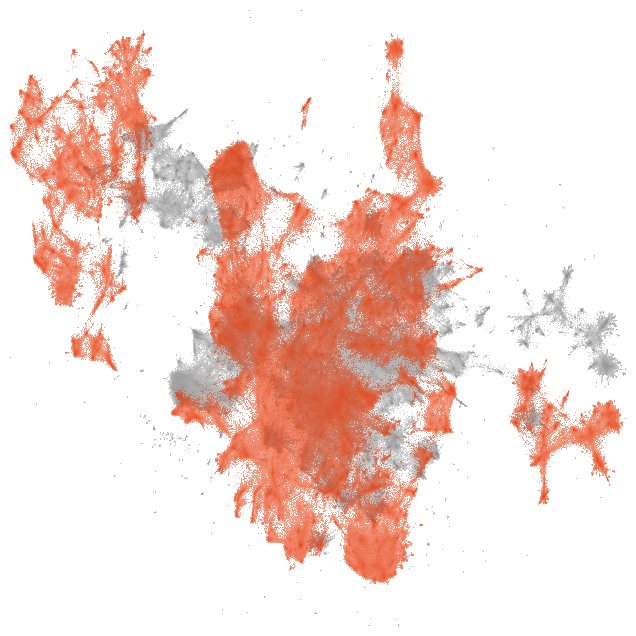

In [2]:
# presentation teaser image

import matplotlib.pyplot as plt
import datashader as ds
from datashader.mpl_ext import dsshow, alpha_colormap
import os

ds_umap_pca = load("all_mpnet_base_v2_umap_pca")
ds_umap = load("all_mpnet_base_v2_umap")

print("Converting subset to DataFrame...")
df_umap_pca = ds_umap_pca.to_pandas()
df_umap = ds_umap.to_pandas()

print("Generating and saving plot...")
fig, ax = plt.subplots(figsize=(8, 8), facecolor="none")
ax.set_facecolor("none")

# First plot the grey UMAP scatterplot
artist_umap = dsshow(
    df_umap,
    ds.Point("x", "y"),
    ds.count(),
    norm="log",
    cmap=alpha_colormap("#808080", min_alpha=80),  # Grey color
    x_range=(-1.0, 1.0),
    y_range=(-1.0, 1.0),
    ax=ax,
)

# Then plot the orange UMAP-PCA scatterplot on top
artist = dsshow(
    df_umap_pca,
    ds.Point("x", "y"),
    ds.count(),
    norm="log",
    cmap=alpha_colormap("#E63E0F", min_alpha=120),
    x_range=(-1.0, 1.0),
    y_range=(-1.0, 1.0),
    ax=ax,
)

# Remove all axes and labels for teaser image
ax.set_xlim(-1.0, 1.0)
ax.set_ylim(-1.0, 1.0)
ax.axis("off")

filepath = os.path.join(img_dir, "deck_teaser.png")
plt.savefig(filepath, format="png", bbox_inches="tight", dpi=300, transparent=True)
print(f"Saved plot to: {filepath}")

plt.show()